# SSH model

### Author : Mathieu Desmarais (python version of the mathematica code of Eric Bitner)
#### Date: 08-06-2026

The goal is to rewrite in python this code that extact third-order nonlinear optical response in the Liouville Space. The model is the SSH model.
This code will be use for starting point for the Spin-Orbite Model for the CuGeO3. 


### packages and modules import

In [ ]:
import numpy as np
import qutip as qt
import scipy.linalg as la
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import multiprocessing as mp

# Force le mode de lancement à 'spawn' (requis pour Windows)
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass # Le mode est déjà configuré

In [100]:
import time

def calculate_response():
    t0 = time.perf_counter()
    
    # --- 1. Initialization Block ---
    # (Setup Hamiltonians, Liouvillians, initial states)
    t1 = time.perf_counter()
    print(f"Initialization took: {t1 - t0:.4f} seconds")
    
    # --- 2. Diagonalization / Pre-computation ---
    # (Finding eigenvalues/eigenvectors if doing exact diag)
    t2 = time.perf_counter()
    print(f"Diagonalization took: {t2 - t1:.4f} seconds")
    
    # --- 3. Main Loop / Parallel Execution ---
    # (The 100k point calculation)
    # results = Parallel(n_jobs=-1)(delayed(...) for ... in ...)
    t3 = time.perf_counter()
    print(f"Main Loop/Parallel execution took: {t3 - t2:.4f} seconds")
    
    print(f"Total time: {t3 - t0:.4f} seconds")

%load_ext line_profiler

%lprun -f calculate_response calculate_response()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
Initialization took: 0.0000 seconds
Diagonalization took: 0.0001 seconds
Main Loop/Parallel execution took: 0.0001 seconds
Total time: 0.0002 seconds


Timer unit: 1e-07 s

Total time: 0.0003033 s

Could not find file C:\Users\MathieuDesmarais\AppData\Local\Temp\ipykernel_15948\3815784785.py
Are you sure you are running this program from the same directory
that you ran the profiler from?
Continuing without the function's contents.

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           
     4         1         44.0     44.0      1.5  
     5                                           
     6                                           
     7                                           
     8         1          6.0      6.0      0.2  
     9         1        976.0    976.0     32.2  
    10                                           
    11                                           
    12                                           
    13         1          7.0      7.0      0.2  
    14         1        707.0    707.0     23.3  
    15                                           
   

### Plot function

In [101]:
def plot_spectrum(w_list, S3_topo, S3_triv, levels=60, figsize=(12, 14), save_path=None):
    """
    Displays a 3x2 figure with 2D spectra for the topological and trivial phases.
    Each subplot has its own (non-shared) color scale to reveal 
    the line shapes of low-amplitude signals.
    """
    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # ==========================================
    # ROW 1: REAL PART
    # ==========================================
    lim_real_topo = np.max(np.abs(np.real(S3_topo)))
    lim_real_triv = np.max(np.abs(np.real(S3_triv)))
    
    c00 = axes[0, 0].contourf(w_list, w_list, np.real(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_real_topo, vmax=lim_real_topo)
    axes[0, 0].set_title(r"Real / Topo ($t_2 > t_1$)")
    axes[0, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c00, ax=axes[0, 0])
    
    c01 = axes[0, 1].contourf(w_list, w_list, np.real(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_real_triv, vmax=lim_real_triv)
    axes[0, 1].set_title(r"Real / Triv ($t_1 > t_2$)")
    fig.colorbar(c01, ax=axes[0, 1])

    # ==========================================
    # ROW 2: IMAGINARY PART
    # ==========================================
    lim_imag_topo = np.max(np.abs(np.imag(S3_topo)))
    lim_imag_triv = np.max(np.abs(np.imag(S3_triv)))
    
    c10 = axes[1, 0].contourf(w_list, w_list, np.imag(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_topo, vmax=lim_imag_topo)
    axes[1, 0].set_title(r"Imag / Topo ($t_2 > t_1$)")
    axes[1, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c10, ax=axes[1, 0])
    
    c11 = axes[1, 1].contourf(w_list, w_list, np.imag(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_triv, vmax=lim_imag_triv)
    axes[1, 1].set_title(r"Imag / Triv ($t_1 > t_2$)")
    fig.colorbar(c11, ax=axes[1, 1])

    # ==========================================
    # ROW 3: ABSOLUTE VALUE
    # ==========================================
    lim_abs_topo = np.max(np.abs(S3_topo))
    lim_abs_triv = np.max(np.abs(S3_triv))
    
    c20 = axes[2, 0].contourf(w_list, w_list, np.abs(S3_topo), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_topo)
    axes[2, 0].set_title(r"Abs / Topo ($t_2 > t_1$)")
    axes[2, 0].set_xlabel(r"$\omega_1$")
    axes[2, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c20, ax=axes[2, 0])
    
    c21 = axes[2, 1].contourf(w_list, w_list, np.abs(S3_triv), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_triv)
    axes[2, 1].set_title(r"Abs / Triv ($t_1 > t_2$)")
    axes[2, 1].set_xlabel(r"$\omega_1$")
    fig.colorbar(c21, ax=axes[2, 1])

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at: {save_path}")
        
    plt.show()

#### Model function (Hamiltonian and operator)

In [102]:
def get_H_and_Js(k, t1, t2):
    """Return the Hamiltonian and the currant operator for k and -k"""
    H_mat = np.array([[0, t1 + t2 * np.exp(-1j * k)],
                      [t1 + t2 * np.exp(1j * k), 0]])
    
    # J(k) = dH/dk
    J_k_mat = np.array([[0, -1j * t2 * np.exp(-1j * k)],
                        [1j * t2 * np.exp(1j * k), 0]])
    
    # J(-k)
    J_minusk_mat = np.array([[0, -1j * t2 * np.exp(1j * k)],
                             [1j * t2 * np.exp(-1j * k), 0]])
    
    return qt.Qobj(H_mat), qt.Qobj(J_k_mat), qt.Qobj(J_minusk_mat)

#### Density Matrix


In [103]:
def get_thermal_state(H, T, mu=0.0):
    """Calcul of the density matrix"""
    evals, evecs = H.eigenstates()
    
    # Fermi-Dirac distribution
    f_occ = 1.0 / (np.exp((evals - mu) / T) + 1.0)
    
    # Construction of the density matrix
    rho_eq = sum([f_occ[i] * evecs[i] * evecs[i].dag() for i in range(len(evals))])
    return rho_eq

#### Random Functions

In [ ]:
def sigma_frohlich(omega, omega_LO, lam, eta, T):
    """Calculates the self-energy (complex scalar)."""
    n_ph = 1.0 / (np.exp(omega_LO / T) - 1.0)
    term1 = (n_ph + 1.0) / ((omega - omega_LO) + 1j * eta)
    term2 = n_ph / ((omega + omega_LO) + 1j * eta)
    return (lam**2) * (term1 + term2)

def get_L_eff(H, omega, omega_LO, lam, eta, T):
    """Constructs the effective Liouvillian superoperator for a given frequency."""
    # Non-Hermitian effective Hamiltonian
    Sigma = sigma_frohlich(omega, omega_LO, lam, eta, T)
    H_eff = H + Sigma * qt.qeye(2)
    
    # L = H_eff (x) I - I (x) H_eff^T
    # In QuTiP, spre acts on the left, spost acts on the right (includes Liouville transposition)
    L_super = qt.spre(H_eff) - qt.spost(H_eff)
    return L_super

def get_green_functions(L_w1, L_w3, tau2, w1, w3, eta):
    """Calculates the three propagators G1(w1), G2(tau2), G3(w3)."""
    # 4x4 identity matrix
    I_4 = np.eye(4)
    
    # Extraction of dense 4x4 matrices (Liouville space) from QuTiP
    L_w1_mat = L_w1.full()
    L_w3_mat = L_w3.full()
    
    # Inversion for the frequency domain
    G1_mat = la.inv((w1 + 1j * eta) * I_4 - L_w1_mat)
    G3_mat = la.inv((w3 + 1j * eta) * I_4 - L_w3_mat)
    
    # Matrix exponential for the population time tau2
    G2_mat = la.expm(-1j * L_w1_mat * tau2) 
    # Note: your code uses L[w1] for tau2, I am keeping this convention.
    
    return G1_mat, G2_mat, G3_mat

def calc_rephasing_S3_k(k, w3, w1, tau2, params):
    t1, t2 = params["t1"], params["t2"]
    eta, T = params["Eta"], params["T"]
    wLO, lam, mu = params["omegaLO"], params["lambda"], params["mu"]
    
    H, J_k, J_minusk = get_H_and_Js(k, t1, t2)
    rho_eq = get_thermal_state(H, T, mu)
    
    # --- Construction of superoperators (following Mathematica) ---
    # Interaction 1 (k)
    JL1 = qt.spre(J_k).full()
    JR1 = qt.spost(J_k).full()
    
    # Interaction 2 (-k)
    JL2 = qt.spre(J_minusk).full()
    JR2 = qt.spost(J_minusk).full()
    
    # Interaction 3 (-k)
    JR3 = qt.spost(J_minusk).full()
    
    # Final trace operator (k)
    JL_out = qt.spre(J_k).full()
    
    # --- Propagators ---
    L_w1 = get_L_eff(H, w1, wLO, lam, eta, T)
    L_w3 = get_L_eff(H, w3, wLO, lam, eta, T)
    G1, G2, G3 = get_green_functions(L_w1, L_w3, tau2, w1, w3, eta)
    
    rho_vec = rho_eq.full().flatten('F')
    
    # --- Liouvillian pathways ---
    path_GSB = G3 @ JR3 @ G2 @ JL2 @ G1 @ JL1 @ rho_vec
    path_SE  = G3 @ JR3 @ G2 @ JL2 @ G1 @ JR1 @ rho_vec
    path_ESA = G3 @ JR3 @ G2 @ JR2 @ G1 @ JR1 @ rho_vec
    
    I_vec = np.eye(2).flatten('F')
    
    # Take the final trace with JL_out
    tr_GSB = -1j * np.dot(I_vec, JL_out @ path_GSB)
    tr_SE  = -1j * np.dot(I_vec, JL_out @ path_SE)
    tr_ESA = -1j * np.dot(I_vec, JL_out @ path_ESA)
    
    total_trace = tr_GSB + tr_SE + tr_ESA
    
    # (Kept for parity with Mathematica output)
    A = -(1/np.pi) * np.imag(np.trace(G3))
    
    return total_trace, A

def integrate_k_response(w1, w3, tau2, params, k_points=100, n_jobs=-1):
    """
    Integrates the S3 response over the full Brillouin zone.
    n_jobs=-1 uses all available computing cores.
    """
    k_array = np.linspace(-np.pi, np.pi, k_points)
    dk = k_array[1] - k_array[0]
    
    # Parallel calculation across all k points
    results = Parallel(n_jobs=n_jobs, require='sharedmem')(
        delayed(calc_rephasing_S3_k)(k, w3, w1, tau2, params) for k in k_array
    )
    
    # Splitting results (total_trace, A) and integration (sum * dk)
    S3_k_list, A_k_list = zip(*results)
    
    S3_macro = np.sum(S3_k_list) * dk / (2 * np.pi)
    A_macro = np.sum(A_k_list) * dk / (2 * np.pi)
    
    return S3_macro, A_macro

def generate_2D_spectrum(w1_list, w3_list, tau2, params, n_kpoints, n_bins):
    k_array = np.linspace(-np.pi, np.pi, n_kpoints)
    dk = k_array[1] - k_array[0]
    # Découpage du tableau en n_bins
    k_chunks = np.array_split(k_array, n_bins)
    
    S3_grid = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    
    for i, w3 in enumerate(w3_list):
        for j, w1 in enumerate(w1_list):
            # Appel parallèle uniquement sur les bins
            results = Parallel(n_jobs=-1, backend="loky", prefer="processes")(
                delayed(integrate_k_response_bulk)(chunk, w1, w3, tau2, params) 
                for chunk in k_chunks
            )
            
            # Somme des résultats retournés par chaque worker
            S3_grid[i, j] = np.sum([r[0] for r in results]) * dk / (2 * np.pi)
            
    return S3_grid

def integrate_k_response_bulk(k_chunk, w1, w3, tau2, params):
    """
    Traite un bloc de k-points en une seule itération dans le processus enfant.
    """
    S3_sum = 0.0
    A_sum = 0.0
    
    # On itère localement dans le worker, ce qui est très rapide
    for k in k_chunk:
        S3_k, A_k = calc_rephasing_S3_k(k, w3, w1, tau2, params)
        S3_sum += S3_k
        A_sum += A_k
        
    return S3_sum, A_sum



### Main Code

In [105]:
%load_ext line_profiler

# --- BLOC MAIN (Crucial sur Windows) ---
if __name__ == "__main__":
    # Paramètres ajustables
    TOTAL_KPOINTS = 100
    N_BINS = 10  # Donne 1000 points par bin (100k / 100)

    w_list = np.linspace(0.5, 1.5, 20) 
    tau2_test = 3.0  # Updated according to your file
    
    params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
    params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}

    
    print(f"Calcul avec {TOTAL_KPOINTS} points divisés en {N_BINS} bins...")
    
    S3_topo = generate_2D_spectrum(
        w_list, w_list, tau2_test, params_topo, 
        n_kpoints=TOTAL_KPOINTS, 
        n_bins=N_BINS
    )

    S3_triv = generate_2D_spectrum(
        w_list, w_list, tau2_test, params_triv, 
        n_kpoints=TOTAL_KPOINTS, 
        n_bins=N_BINS
    )

'''
if __name__ == '__main__':
    # --- Parameters aligned with Mathematica ---
    # Restricted grid [0.5, 1.5] to avoid the population peak at w=0
    w_list = np.linspace(0.5, 1.5, 20) 
    tau2_test = 3.0  # Updated according to your file
    
    params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
    params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}

    print("Calculating topological phase (may take some time)...")
    S3_topo = generate_2D_spectrum(w_list, w_list, tau2_test, params_topo, k_points=10)

    print("Calculating trivial phase...")
    S3_triv = generate_2D_spectrum(w_list, w_list, tau2_test, params_triv, k_points=50)

    %lprun -f calculate_response calculate_response()
'''    
%lprun -f calculate_response calculate_response()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
Calcul avec 100 points divisés en 10 bins...


ModuleNotFoundError: No module named '_posixsubprocess'

### Plot 

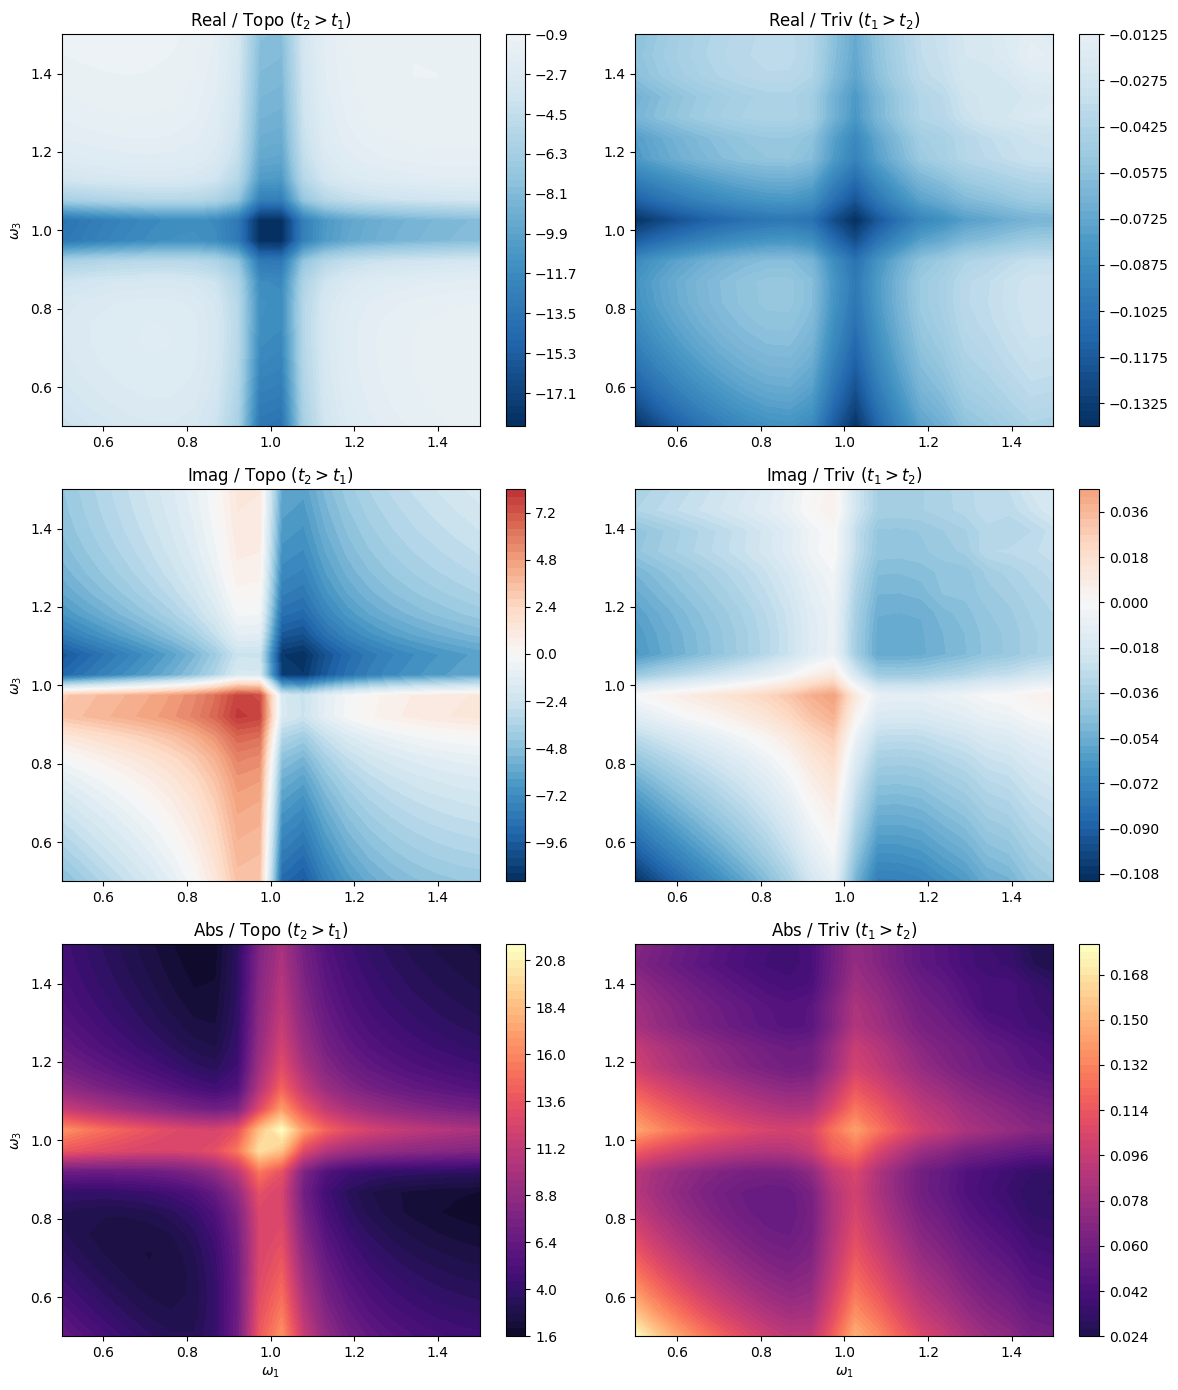

In [ ]:
plot_spectrum(w_list, S3_topo, S3_triv)